# LIBERO Prompt Variant Rollout Analysis

This notebook loads raw rollout output from multiple CSV files and provides:
- overall statistics (combined across all files)
- success-rate heatmap by task and prompt variant
- mean episode-length heatmap by task and prompt variant
- success-rate bar plot by variant with the original prompt as a baseline line

## 1. Import Required Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

## 2. Load and Parse Raw Output Data

In [3]:
# Define your CSV file paths here - add as many as needed
csv_paths = [
    Path("../language_diagnostics/outputs/goal/nr1/28314519/libero_prompt_variant_rollouts_raw.csv"),
    Path("../language_diagnostics/outputs/objects/nr1/28314521/libero_prompt_variant_rollouts_raw.csv"),
    Path("../language_diagnostics/outputs/spatial/nr1/28314517/libero_prompt_variant_rollouts_raw.csv"),
    Path("../language_diagnostics/outputs/goal/nr3/28343413/libero_prompt_variant_rollouts_raw.csv"),
    Path("../language_diagnostics/outputs/objects/nr3/28343417/libero_prompt_variant_rollouts_raw.csv"),
]

# Resolve paths with fallback options
resolved_paths = []
for csv_path in csv_paths:
    p = Path(csv_path)
    if p.exists():
        resolved_paths.append(p)
    else:
        # Try alternative paths
        alternatives = [
            p,
            Path("language_diagnostics") / csv_path.name,
            Path("outputs") / csv_path.name,
        ]
        found = False
        for alt_path in alternatives:
            if alt_path.exists():
                resolved_paths.append(alt_path)
                found = True
                break
        if not found:
            raise FileNotFoundError(f"Could not find {csv_path} or alternatives")

if not resolved_paths:
    raise FileNotFoundError(f"No CSV files found. Checked: {csv_paths}")

# Load and combine all CSV files
dfs = []
for csv_path in resolved_paths:
    print(f"Loading: {csv_path.resolve()}")
    df_tmp = pd.read_csv(csv_path)
    df_tmp["source_file"] = csv_path.name
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined {len(dfs)} files into one dataset")

required_cols = {
    "suite", "task_id", "task_description", "variant_type", "success", "episode_length", "rollout_index"
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(
        "Missing required columns for analysis: "
        f"{sorted(missing)}. Available columns: {list(df.columns)}"
    )

# Normalize types for robust analysis.
df["success"] = df["success"].astype(bool)
df["episode_length"] = pd.to_numeric(df["episode_length"], errors="coerce")

# Build labels: keep a rich label for tables and a compact one for heatmaps.
df["task_label"] = (
    df["suite"].astype(str)
    + " | task_"
    + df["task_id"].astype(str)
    + " | "
    + df["task_description"].astype(str).str.slice(0, 55)
)

df["task_short"] = (
    df["suite"].astype(str)
    + " | t"
    + df["task_id"].astype(str)
    + " | "
    + np.where(
        df["task_description"].str.len() > 28,
        df["task_description"].str.slice(0, 28) + "…",
        df["task_description"],
    )
)

print(f"Rows (rollouts): {len(df)}")
print(f"Unique tasks: {df['task_label'].nunique()}")
print(f"Unique variants: {df['variant_type'].nunique()}")
print(f"Unique source files: {df['source_file'].nunique()}")
print(f"\nSource file breakdown:")
print(df["source_file"].value_counts())
df.head()

Loading: /zhome/ca/2/206287/vla-robotics/language_diagnostics/outputs/goal/nr1/28314519/libero_prompt_variant_rollouts_raw.csv
Loading: /zhome/ca/2/206287/vla-robotics/language_diagnostics/outputs/objects/nr1/28314521/libero_prompt_variant_rollouts_raw.csv
Loading: /zhome/ca/2/206287/vla-robotics/language_diagnostics/outputs/spatial/nr1/28314517/libero_prompt_variant_rollouts_raw.csv
Loading: /zhome/ca/2/206287/vla-robotics/language_diagnostics/outputs/goal/nr3/28343413/libero_prompt_variant_rollouts_raw.csv
Loading: /zhome/ca/2/206287/vla-robotics/language_diagnostics/outputs/objects/nr3/28343417/libero_prompt_variant_rollouts_raw.csv

Combined 5 files into one dataset
Rows (rollouts): 4000
Unique tasks: 10
Unique variants: 8
Unique source files: 1

Source file breakdown:
source_file
libero_prompt_variant_rollouts_raw.csv    4000
Name: count, dtype: int64


,suite,task_id,task_description,episode_seed_base,variant_type,variant_index,prompt,rollout_index,episode_seed,success,episode_length,source_file,task_label,task_short
0,goal,0,open the middle drawer of the cabinet,200000,original,0,open the middle drawer of the cabinet,0,200000,False,280,libero_prompt_variant_rollouts_raw.csv,goal | task_0 | open the middle drawer of the ...,goal | t0 | open the middle drawer of th…
1,goal,0,open the middle drawer of the cabinet,200000,original,0,open the middle drawer of the cabinet,1,200001,True,133,libero_prompt_variant_rollouts_raw.csv,goal | task_0 | open the middle drawer of the ...,goal | t0 | open the middle drawer of th…
2,goal,0,open the middle drawer of the cabinet,200000,original,0,open the middle drawer of the cabinet,2,200002,True,120,libero_prompt_variant_rollouts_raw.csv,goal | task_0 | open the middle drawer of the ...,goal | t0 | open the middle drawer of th…
3,goal,0,open the middle drawer of the cabinet,200000,original,0,open the middle drawer of the cabinet,3,200003,False,280,libero_prompt_variant_rollouts_raw.csv,goal | task_0 | open the middle drawer of the ...,goal | t0 | open the middle drawer of th…
4,goal,0,open the middle drawer of the cabinet,200000,original,0,open the middle drawer of the cabinet,4,200004,True,185,libero_prompt_variant_rollouts_raw.csv,goal | task_0 | open the middle drawer of the ...,goal | t0 | open the middle drawer of th…


## 3. Calculate Overall Statistics

In [4]:
overall = {
    "num_rollouts": len(df),
    "num_tasks": df["task_label"].nunique(),
    "num_variants": df["variant_type"].nunique(),
    "overall_success_rate": df["success"].mean(),
    "overall_mean_episode_length": df["episode_length"].mean(),
    "overall_median_episode_length": df["episode_length"].median(),
    "mean_episode_length_successful": df[df["success"]]["episode_length"].mean(),
}

overall_df = pd.DataFrame([overall])
overall_df[["overall_success_rate"]] = overall_df[["overall_success_rate"]] * 100
overall_df = overall_df.rename(columns={"overall_success_rate": "overall_success_rate_percent"})
display(overall_df.round(2))

per_variant = (
    df.groupby("variant_type", as_index=False)
    .agg(
        rollouts=("success", "size"),
        success_rate=("success", "mean"),
        mean_episode_length=("episode_length", "mean"),
        median_episode_length=("episode_length", "median"),
    )
    .sort_values("success_rate", ascending=False)
)
per_variant["success_rate_percent"] = per_variant["success_rate"] * 100

# Calculate mean episode length for successful trajectories per variant
per_variant["mean_episode_length_successful"] = per_variant["variant_type"].apply(
    lambda v: df[(df["variant_type"] == v) & (df["success"])]["episode_length"].mean()
)

display(per_variant.round(2))

,num_rollouts,num_tasks,num_variants,overall_success_rate_percent,overall_mean_episode_length,overall_median_episode_length,mean_episode_length_successful
0,4000,10,8,37.1,223.38,280.0,127.38


,variant_type,rollouts,success_rate,mean_episode_length,median_episode_length,success_rate_percent,mean_episode_length_successful
2,original,500,0.84,149.67,127.5,83.8,124.48
4,quickly,500,0.63,188.30,145.5,62.8,133.98
6,verb_paraphrase,500,0.50,201.29,270.5,50.2,123.20
0,carefully,500,0.46,213.17,280.0,46.0,134.72
3,politeness,500,0.33,230.05,280.0,33.0,128.63
1,do_not_move,500,0.15,254.77,280.0,15.2,114.03
5,sentence_structure,500,0.06,269.88,280.0,5.6,99.21
7,verbosity,500,0.00,279.89,280.0,0.2,223.00


## 4. Create Success vs Task Heatmap

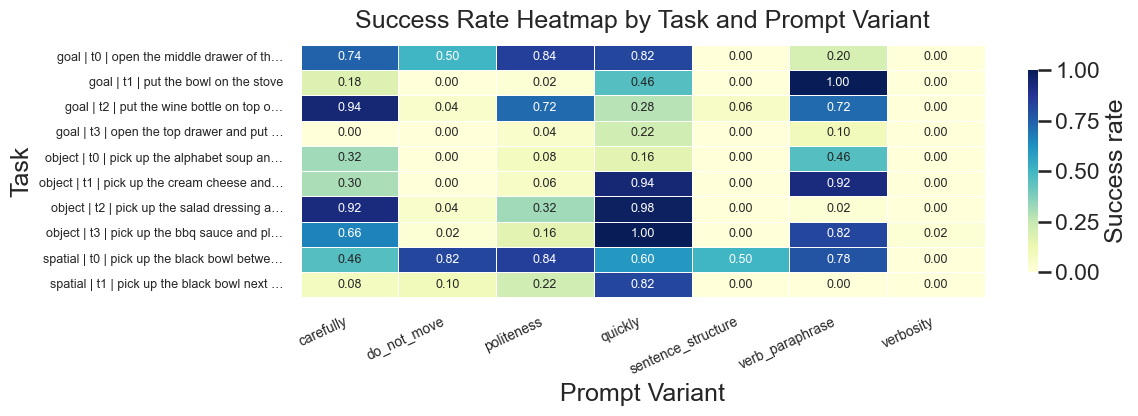

In [5]:
success_pivot = (
    df[df["variant_type"] != "original"]
    .groupby(["task_short", "variant_type"], as_index=False)["success"]
    .mean()
    .pivot(index="task_short", columns="variant_type", values="success")
)

n_tasks = len(success_pivot)
fig_h = min(max(4.5, 0.45 * n_tasks), 11)

plt.figure(figsize=(12, fig_h))
ax = sns.heatmap(
    success_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Success rate", "shrink": 0.8},
    annot_kws={"size": 9},
)
ax.set_title("Success Rate Heatmap by Task and Prompt Variant", pad=12)
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Task")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 5. Create Mean Episode Length vs Task Heatmap

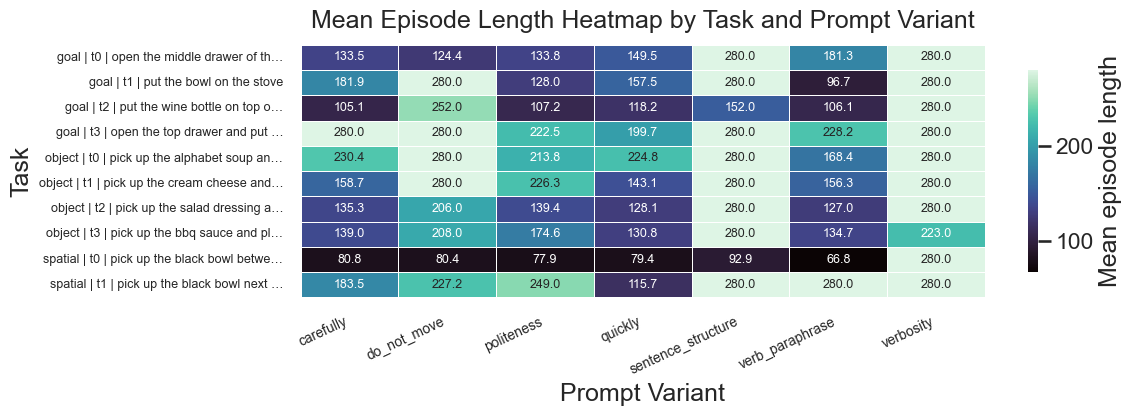

In [30]:
# Calculate mean episode length for each task-variant combination
# Use successful rollouts if available, otherwise fall back to all rollouts
def get_mean_episode_length(group_df):
    successful = group_df[group_df["success"]]
    if len(successful) > 0:
        return successful["episode_length"].mean()
    else:
        return group_df["episode_length"].mean()

length_data = df[df["variant_type"] != "original"].groupby(["task_short", "variant_type"]).apply(get_mean_episode_length).reset_index()
length_data.columns = ["task_short", "variant_type", "episode_length"]
length_pivot = length_data.pivot(index="task_short", columns="variant_type", values="episode_length")

n_tasks = len(length_pivot)
fig_h = min(max(4.5, 0.45 * n_tasks), 11)

plt.figure(figsize=(12, fig_h))
ax = sns.heatmap(
    length_pivot,
    annot=True,
    fmt=".1f",
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean episode length", "shrink": 0.8},
    annot_kws={"size": 9},
)
ax.set_title("Mean Episode Length Heatmap by Task and Prompt Variant", pad=12)
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Task")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## 6. Create Success Rate Bar Plot with Baseline Comparison

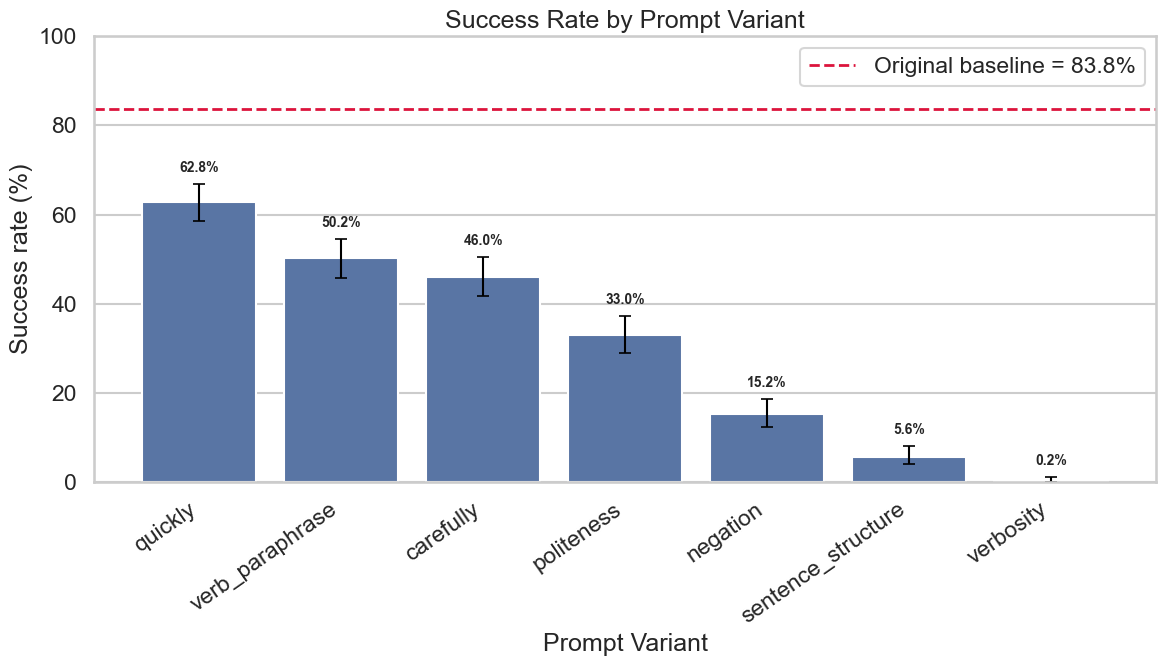

In [29]:
# Optional: rename variants for display on x-axis
variant_name_map = {
    "do_not_move": "negation",
}

variant_stats = (
    df.groupby("variant_type", as_index=False)
    .agg(
        success_rate=("success", "mean"),
        rollouts=("success", "size"),
    )
    .sort_values("success_rate", ascending=False)
)

original_row = variant_stats.loc[variant_stats["variant_type"] == "original", "success_rate"]
if original_row.empty:
    raise ValueError("No 'original' variant found in data. Cannot draw baseline line.")

original_baseline = float(original_row.iloc[0])

# Compute 95% confidence intervals for a binomial proportion using the Wilson interval.
def wilson_interval(success_rate, n, z=1.96):
    if n <= 0:
        return 0.0, 0.0

    denom = 1.0 + (z ** 2) / n
    center = (success_rate + (z ** 2) / (2.0 * n)) / denom

    margin = (
        z
        * np.sqrt(
            (success_rate * (1.0 - success_rate) / n)
            + (z ** 2) / (4.0 * n ** 2)
        )
        / denom
    )

    lower = max(0.0, center - margin)
    upper = min(1.0, center + margin)

    return lower, upper


variant_stats_plot = variant_stats[
    variant_stats["variant_type"] != "original"
].copy()

# Add display names
variant_stats_plot["display_name"] = (
    variant_stats_plot["variant_type"]
    .map(variant_name_map)
    .fillna(variant_stats_plot["variant_type"])
)

variant_stats_plot["success_rate_percent"] = (
    variant_stats_plot["success_rate"] * 100
)

ci_bounds = variant_stats_plot.apply(
    lambda row: wilson_interval(
        float(row["success_rate"]),
        int(row["rollouts"])
    ),
    axis=1,
)

variant_stats_plot[["ci_lower", "ci_upper"]] = pd.DataFrame(
    ci_bounds.tolist(),
    index=variant_stats_plot.index,
)

variant_stats_plot["ci_lower_percent"] = (
    variant_stats_plot["ci_lower"] * 100
)

variant_stats_plot["ci_upper_percent"] = (
    variant_stats_plot["ci_upper"] * 100
)

variant_stats_plot["ci_err_lower"] = (
    variant_stats_plot["success_rate_percent"]
    - variant_stats_plot["ci_lower_percent"]
)

variant_stats_plot["ci_err_upper"] = (
    variant_stats_plot["ci_upper_percent"]
    - variant_stats_plot["success_rate_percent"]
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=variant_stats_plot,
    x="display_name",   # uses renamed labels
    y="success_rate_percent",
    color="#4C72B0",
    errorbar=None,
)

x_positions = np.arange(len(variant_stats_plot))

ax.errorbar(
    x=x_positions,
    y=variant_stats_plot["success_rate_percent"],
    yerr=[
        variant_stats_plot["ci_err_lower"],
        variant_stats_plot["ci_err_upper"],
    ],
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=4,
    capthick=1.2,
)

ax.axhline(
    original_baseline * 100,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Original baseline = {original_baseline * 100:.1f}%",
)

ax.set_title("Success Rate by Prompt Variant")
ax.set_xlabel("Prompt Variant")
ax.set_ylabel("Success rate (%)")

# Force y-axis to max out at 100%
ax.set_ylim(0, 100)

plt.xticks(rotation=35, ha="right")

# Put percentage labels ABOVE the confidence interval bars
for i, row in variant_stats_plot.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["ci_upper_percent"] + 2,
        f'{row["success_rate_percent"]:.1f}%',
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.legend()

plt.tight_layout()
plt.show()